# Indicador de Compra/Venda Baseado em Sazonalidade Semanal e Volatilidade (AAPL)

**Ativo analisado:** AAPL (Apple Inc., NASDAQ) · **Período:** 02/01/2015 a 29/11/2024 (2.495 pregões, ~10 anos de dados reais)

Projeto de portfólio que testa estatisticamente o "efeito de fim de semana" em ações — a ideia de que investidores reduzem posições antes do fim de semana (vendendo na sexta e recomprando na segunda) por aversão à incerteza — e faz o backtest de estratégias que tentam se aproveitar (ou evitar) esse padrão, incluindo uma estratégia **contrária ao efeito manada** (ficar sempre comprado no gap do fim de semana, o oposto do que a maioria faz) e uma estratégia que combina buy & hold com **opções** para controlar o risco especificamente nesse intervalo.

Feito por **Jorge Rachid**, estudante de Estatística (UFF), unindo formação quantitativa com experiência prática em mercado financeiro (assessoria de investimentos e mesa proprietária).

Continuação do projeto [`analise-estatistica-acoes`](https://github.com/jorgerachid1/analise-estatistica-acoes), com uma janela histórica de ~10 anos (2015–2024).

## Hipótese

Em períodos de muita incerteza, investidores tendem a evitar ficar posicionados durante o fim de semana. Como não há pregão no sábado/domingo, o retorno observado numa segunda-feira mede exatamente essa variação (fechamento de sexta → fechamento de segunda) — o "gap de fim de semana".

**Perguntas respondidas:**
1. O retorno de segunda-feira é, em média, diferente dos demais dias da semana?
2. Esse efeito é mais forte em semanas de alta volatilidade? (usando o **VIX**, o índice de volatilidade implícita do mercado americano, como medida de "alta volatilidade")
3. Uma estratégia que compra no fechamento de sexta e vende no fechamento de segunda supera o buy & hold?
4. Uma estratégia **contrária ao efeito manada** — ficar comprado no gap do fim de semana sistematicamente, todo fim de semana — funciona melhor em determinados níveis de VIX?
5. É possível combinar o buy & hold com uma proteção via **opções** especificamente para o risco do fim de semana?
6. Aplicando a mesma lógica ao **S&P 500**: um Buy & Hold que só usa opções como "booster" (comprando uma put) nos fins de semana em que o VIX está muito alto — vale a pena?

**Aviso:** este notebook é um projeto educacional/estatístico, não uma recomendação de investimento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("aapl_precos_historicos.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df["log_return"] = np.log(df["AAPL.Close"] / df["AAPL.Close"].shift(1))
df["weekday"] = df["Date"].dt.day_name()
df = df.dropna(subset=["log_return"]).reset_index(drop=True)

# Índice VIX (CBOE Volatility Index) — medida padrão de mercado para volatilidade implícita/"medo".
vix = pd.read_csv("vix_historico.csv", parse_dates=["Date"])
vix = vix.rename(columns={"VIX_Close": "vix"})
df = df.merge(vix, on="Date", how="left")
df["vix"] = df["vix"].ffill()  # feriados/datas sem pregão de VIX (raro): usa último valor conhecido

print(f"Período: {df['Date'].min().date()} a {df['Date'].max().date()}")
print(f"Número de pregões: {len(df)}")
print(f"Pregões com VIX disponível: {df['vix'].notna().sum()}")
df.head()


Período: 2015-01-05 a 2024-11-29
Número de pregões: 2494
Pregões com VIX disponível: 2494


,Date,AAPL.Open,AAPL.High,AAPL.Low,AAPL.Close,AAPL.Volume,log_return,weekday,vix
0,2015-01-05,24.1156,24.1957,23.4742,23.6613,257142000,-0.0286,Monday,19.9200
1,2015-01-06,23.7259,23.9240,23.3005,23.6635,263188400,0.0001,Tuesday,21.1200
2,2015-01-07,23.8728,24.0955,23.7615,23.9953,160423600,0.0139,Wednesday,19.3100
3,2015-01-08,24.3249,24.9752,24.2069,24.9173,237458000,0.0377,Thursday,17.0100
4,2015-01-09,25.0910,25.2201,24.5431,24.9440,214798000,0.0011,Friday,17.5500


## 1. Retorno médio por dia da semana

             mean    std  count  mean_pct
weekday                                  
Monday     0.0021 0.0190    464    0.2082
Tuesday    0.0011 0.0166    513    0.1058
Wednesday  0.0017 0.0176    512    0.1742
Thursday  -0.0003 0.0181    505   -0.0314
Friday     0.0001 0.0184    500    0.0070


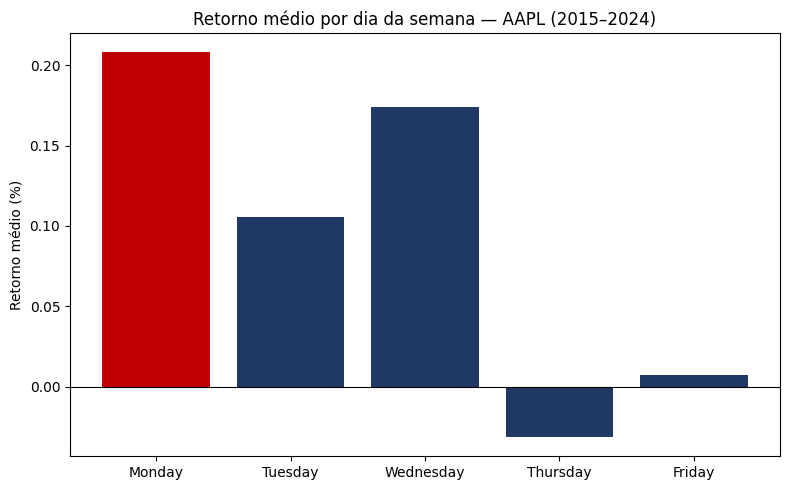

In [2]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
by_day = df.groupby("weekday")["log_return"].agg(["mean", "std", "count"]).reindex(order)
by_day["mean_pct"] = by_day["mean"] * 100
print(by_day)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#1f3864" if d != "Monday" else "#c00000" for d in order]
ax.bar(order, by_day["mean_pct"], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Retorno médio (%)")
ax.set_title("Retorno médio por dia da semana — AAPL (2015–2024)")
plt.tight_layout()
plt.savefig("retorno_por_dia.png", dpi=110)
plt.show()


## 2. Teste de hipótese: segunda-feira vs. demais dias

In [3]:
mondays = df.loc[df["weekday"] == "Monday", "log_return"]
others = df.loc[df["weekday"] != "Monday", "log_return"]

t_stat, p_value = stats.ttest_ind(mondays, others, equal_var=False)
print(f"Retorno médio segunda-feira: {mondays.mean()*100:.4f}%")
print(f"Retorno médio demais dias: {others.mean()*100:.4f}%")
print(f"Estatística t (Welch): {t_stat:.4f}")
print(f"p-valor: {p_value:.4f}")
print("Diferença estatisticamente significativa a 5%?", "Sim" if p_value < 0.05 else "Não")


Retorno médio segunda-feira: 0.2082%
Retorno médio demais dias: 0.0646%
Estatística t (Welch): 1.4840
p-valor: 0.1383
Diferença estatisticamente significativa a 5%? Não


## 3. O efeito é mais forte em regimes de alta volatilidade? (medido pelo VIX)

**O que conta como "alta volatilidade"?** Em vez de definir "alta volatilidade" de forma arbitrária (ex: acima da mediana da própria amostra), este notebook usa o **VIX** — o índice de volatilidade implícita da CBOE, calculado a partir de opções do S&P 500 e amplamente usado no mercado como termômetro de medo/incerteza — porque é uma referência padronizada, conhecida do mercado, e não depende de uma janela arbitrária calculada sobre o próprio ativo. As faixas usadas seguem a leitura convencional de mercado para o nível do VIX:

| Faixa | VIX | Leitura de mercado |
|---|---|---|
| Baixa | < 15 | Complacência / baixa incerteza |
| Moderada | 15 – 20 | Volatilidade "normal" |
| Alta | 20 – 30 | Incerteza elevada |
| Muito alta | > 30 | Estresse / crise |

O VIX de cada sexta-feira (ou último pregão antes do gap) é usado para classificar o regime — sem look-ahead, pois é o valor conhecido no momento em que a posição do fim de semana seria decidida.

                   mean    std  count  mean_pct
faixa_vix_prev                                 
Baixa (<15)      0.0026 0.0123    185    0.2569
Moderada (15-20) 0.0003 0.0173    136    0.0290
Alta (20-30)     0.0037 0.0202    117    0.3709
Muito alta (>30) 0.0018 0.0458     25    0.1835


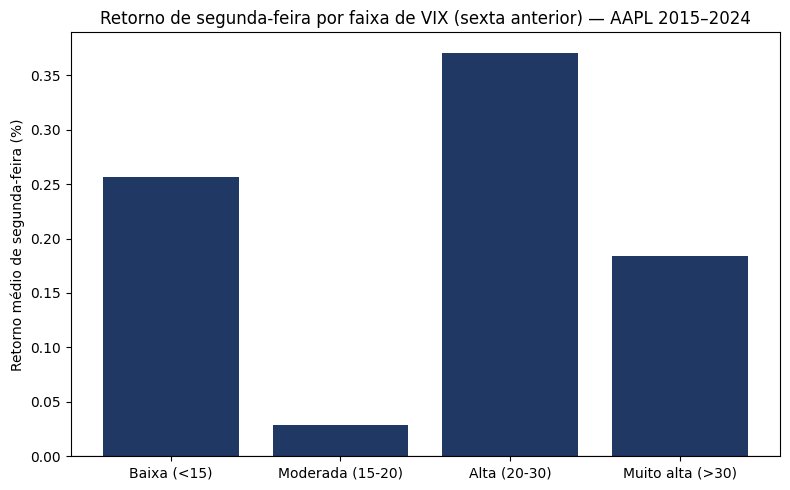

In [4]:
def faixa_vix(v):
    if pd.isna(v):
        return np.nan
    if v < 15:
        return "Baixa (<15)"
    elif v < 20:
        return "Moderada (15-20)"
    elif v < 30:
        return "Alta (20-30)"
    else:
        return "Muito alta (>30)"

ordem_faixas = ["Baixa (<15)", "Moderada (15-20)", "Alta (20-30)", "Muito alta (>30)"]

df["vix_prev"] = df["vix"].shift(1)   # VIX do pregão anterior (sexta, no caso do gap) — sem look-ahead
df["faixa_vix_prev"] = df["vix_prev"].apply(faixa_vix)

df_mon = df.loc[df["weekday"] == "Monday"].dropna(subset=["faixa_vix_prev"]).copy()
resumo_vix = df_mon.groupby("faixa_vix_prev")["log_return"].agg(["mean", "std", "count"]).reindex(ordem_faixas)
resumo_vix["mean_pct"] = resumo_vix["mean"] * 100
print(resumo_vix)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumo_vix.index, resumo_vix["mean_pct"], color="#1f3864")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Retorno médio de segunda-feira (%)")
ax.set_title("Retorno de segunda-feira por faixa de VIX (sexta anterior) — AAPL 2015–2024")
plt.tight_layout()
plt.savefig("retorno_segunda_por_vix.png", dpi=110)
plt.show()


In [5]:
# Teste de hipótese formal: regime de VIX baixo (<20) vs. alto (>=20)
baixo_vix = df_mon.loc[df_mon["vix_prev"] < 20, "log_return"]
alto_vix = df_mon.loc[df_mon["vix_prev"] >= 20, "log_return"]

t_stat2, p_value2 = stats.ttest_ind(alto_vix, baixo_vix, equal_var=False)
print(f"Retorno médio segunda-feira com VIX < 20 (regime baixo/moderado): {baixo_vix.mean()*100:.4f}%  (n={len(baixo_vix)})")
print(f"Retorno médio segunda-feira com VIX >= 20 (regime alto/muito alto): {alto_vix.mean()*100:.4f}%  (n={len(alto_vix)})")
print(f"Estatística t (Welch): {t_stat2:.4f}")
print(f"p-valor: {p_value2:.4f}")
print("Diferença estatisticamente significativa a 5%?", "Sim" if p_value2 < 0.05 else "Não")


Retorno médio segunda-feira com VIX < 20 (regime baixo/moderado): 0.1604%  (n=321)
Retorno médio segunda-feira com VIX >= 20 (regime alto/muito alto): 0.3379%  (n=142)
Estatística t (Welch): 0.7532
p-valor: 0.4523
Diferença estatisticamente significativa a 5%? Não


## 4. Backtest de estratégias com a ação (sem opções)

In [6]:
d = df.set_index("Date").copy()
d["ret"] = d["log_return"]

# Estratégia 1: Buy & Hold
d["strat_buyhold"] = d["ret"]

# Estratégia 2: "Contra o efeito manada" (aproveita o gap) — compra no fechamento de sexta, vende no
# fechamento de segunda seguinte, fica fora do mercado nos demais dias (terça a sexta). Chamada de
# "contra o efeito manada" porque faz exatamente o oposto do que a maioria dos investidores faz
# (vender antes do fim de semana): ela SÓ fica posicionada durante o fim de semana.
d["strat_aproveita_gap"] = np.where(d.index.day_name() == "Monday", d["ret"], 0.0)

# Estratégia 3: "Evita o gap" — o oposto: fica posicionado de segunda a sexta, mas fecha a posição
# na sexta e reabre na segunda (ou seja, ganha todos os dias MENOS o retorno de segunda-feira).
d["strat_evita_gap"] = np.where(d.index.day_name() == "Monday", 0.0, d["ret"])

# Estratégia 4: "Contra o efeito manada" + filtro de VIX alto — só entra no gap do fim de semana
# se o VIX da sexta anterior estava em regime de alta volatilidade (>= 20).
vix_prev_d = d["vix"].shift(1)
cond = (d.index.day_name() == "Monday") & (vix_prev_d >= 20)
d["strat_gap_filtro_vix"] = np.where(cond, d["ret"], 0.0)

estrategias = ["strat_buyhold", "strat_aproveita_gap", "strat_evita_gap", "strat_gap_filtro_vix"]
nomes = {
    "strat_buyhold": "Buy & Hold",
    "strat_aproveita_gap": "Contra o efeito manada (comprado no gap, todo fim de semana)",
    "strat_evita_gap": "Evita o gap (fora no fim de semana)",
    "strat_gap_filtro_vix": "Contra o efeito manada + filtro de VIX alto (>=20)",
}

def metricas(r, nome):
    r = r.dropna()
    equity = np.exp(r.cumsum())
    total_return = equity.iloc[-1] - 1
    n_years = (r.index[-1] - r.index[0]).days / 365.25
    ann_return = (1 + total_return) ** (1 / n_years) - 1
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (r.mean() * 252) / ann_vol if ann_vol > 0 else np.nan
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()
    n_trades = (r != 0).sum()
    win_rate = (r[r != 0] > 0).mean() if n_trades > 0 else np.nan
    return {
        "Estratégia": nome,
        "Retorno total": total_return,
        "Retorno anualizado": ann_return,
        "Volatilidade anualizada": ann_vol,
        "Sharpe (rf=0)": sharpe,
        "Max drawdown": max_dd,
        "Taxa de acerto": win_rate,
        "Nº de dias com posição": n_trades,
    }, equity

resultados = []
equities = {}
for col in estrategias:
    m, eq = metricas(d[col], nomes[col])
    resultados.append(m)
    equities[nomes[col]] = eq

res_df = pd.DataFrame(resultados).set_index("Estratégia")
res_df


,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Max drawdown,Taxa de acerto,Nº de dias com posição
Estratégia,,,,,,,
Buy & Hold,8.7477,0.2586,0.2855,0.8060,-0.3852,0.5322,2488
"Contra o efeito manada (comprado no gap, todo fim de semana)",1.6273,0.1025,0.1309,0.7456,-0.2199,0.5788,463
Evita o gap (fora no fim de semana),2.7102,0.1416,0.2539,0.5218,-0.3517,0.5215,2025
Contra o efeito manada + filtro de VIX alto (>=20),0.6157,0.0497,0.1002,0.4838,-0.2146,0.6170,141


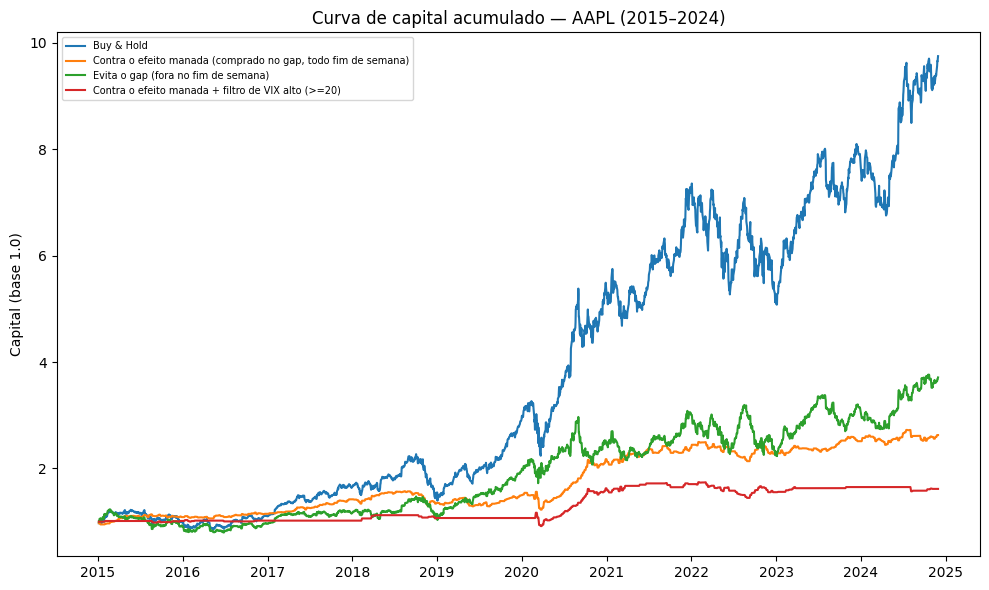

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for nome, eq in equities.items():
    ax.plot(eq.index, eq.values, label=nome)
ax.set_title("Curva de capital acumulado — AAPL (2015–2024)")
ax.set_ylabel("Capital (base 1.0)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("curva_de_capital.png", dpi=110)
plt.show()


## 5. Estratégia "contra o efeito manada" detalhada por nível de VIX

A estratégia "contra o efeito manada" (comprar no fechamento de sexta, vender no fechamento de segunda, sistematicamente, todo fim de semana) é testada agora quebrada pelas mesmas faixas de VIX definidas na Seção 3 — para responder diretamente se ela funciona melhor quando a volatilidade de mercado (medida pelo VIX) está elevada.

                  count  retorno_medio_pct  retorno_acumulado_pct  \
faixa_vix_prev                                                      
Baixa (<15)         185             0.2569                60.8578   
Moderada (15-20)    136             0.0290                 4.0170   
Alta (20-30)        117             0.3709                54.3277   
Muito alta (>30)     25             0.1835                 4.6956   

                  taxa_de_acerto  
faixa_vix_prev                    
Baixa (<15)               0.5784  
Moderada (15-20)          0.5441  
Alta (20-30)              0.6068  
Muito alta (>30)          0.6400  


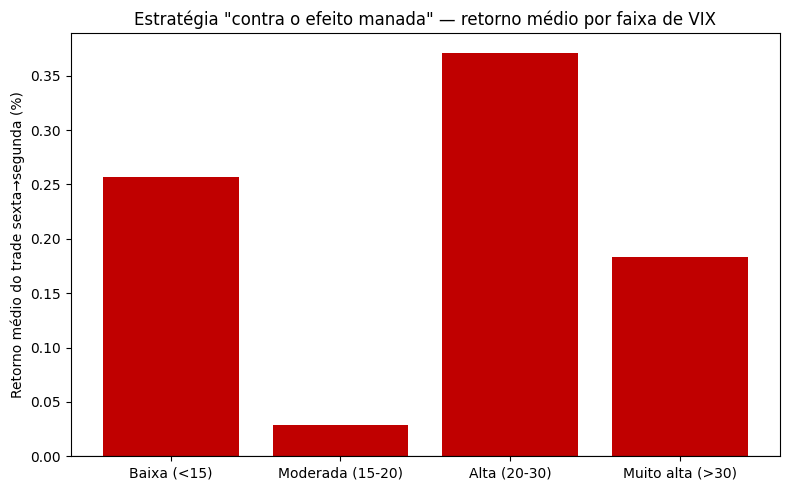

In [8]:
trades_gap = df_mon.copy()  # cada linha é um "trade" do gap de sexta->segunda, com a faixa de VIX da sexta anterior
resumo_estrategia_vix = trades_gap.groupby("faixa_vix_prev")["log_return"].agg(["mean", "std", "count"]).reindex(ordem_faixas)
resumo_estrategia_vix["retorno_medio_pct"] = resumo_estrategia_vix["mean"] * 100
resumo_estrategia_vix["retorno_acumulado_pct"] = (np.exp(trades_gap.groupby("faixa_vix_prev")["log_return"].sum()) - 1).reindex(ordem_faixas) * 100
resumo_estrategia_vix["taxa_de_acerto"] = trades_gap.groupby("faixa_vix_prev")["log_return"].apply(lambda x: (x > 0).mean()).reindex(ordem_faixas)
print(resumo_estrategia_vix[["count", "retorno_medio_pct", "retorno_acumulado_pct", "taxa_de_acerto"]])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumo_estrategia_vix.index, resumo_estrategia_vix["retorno_medio_pct"], color="#c00000")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Retorno médio do trade sexta→segunda (%)")
ax.set_title('Estratégia "contra o efeito manada" — retorno médio por faixa de VIX')
plt.tight_layout()
plt.savefig("gap_por_faixa_vix.png", dpi=110)
plt.show()


## 6. Estratégia combinada: Buy & Hold + collar de opções no fim de semana

**Ideia:** em vez de escolher entre "ficar sempre investido" (buy & hold, que captura toda a alta de longo prazo, mas leva o risco do gap de fim de semana) e "sair do mercado no fim de semana" (que reduz risco, mas abre mão de retorno), a estratégia combinada faz o seguinte:

1. **Mantém a ação o tempo todo**, como no buy & hold — nunca vende a posição.
2. **A cada sexta-feira**, monta um *collar* (trava de opções) que vale só até a segunda-feira seguinte (ou próximo pregão, em caso de feriado):
   - **Compra uma put** (opção de venda) fora do dinheiro (strike ~3% abaixo do preço de sexta) para se proteger de uma queda forte no gap do fim de semana.
   - **Vende uma call** (opção de compra) fora do dinheiro (strike ~3% acima do preço de sexta) para financiar a compra da put — um *collar* aproximadamente sem custo ("zero-cost collar").
3. Na segunda-feira (ou próximo pregão), o collar expira: se o preço caiu abaixo do strike da put, a put paga a diferença (protege a queda); se o preço subiu acima do strike da call, a call vendida é exercida contra a posição (o upside do fim de semana fica limitado a esse strike); entre os dois strikes, o resultado é simplesmente a variação da ação, sem opções agindo.

Ou seja: durante a semana (terça a sexta) a estratégia se comporta como buy & hold puro. Apenas o intervalo sexta→segunda tem seu risco (e seu potencial) limitado por opções — exatamente o intervalo em que a hipótese de sazonalidade prevê maior incerteza.

### Limitação importante dos dados

Este ambiente não tem acesso a cotações históricas reais de opções da AAPL (a API do provedor de dados de opções não está disponível aqui). Para tornar o backtest possível, os prêmios de put e call são **estimados com o modelo de Black-Scholes**, usando como proxy de volatilidade implícita a **volatilidade realizada móvel de 21 pregões** calculada na própria sexta-feira (sem look-ahead) e taxa livre de risco igual a zero (aproximação razoável para um contrato de ~3 dias corridos). Isso é uma **simulação teórica dos prêmios**, não um backtest com preços de opções realmente negociados — o objetivo é ilustrar o mecanismo e a lógica de risco/retorno, não fornecer um resultado pronto para operar.

In [9]:
def black_scholes_put_call(S, K, T, sigma, r=0.0):
    """Retorna (call, put) premium via Black-Scholes. T em anos, sigma anualizado."""
    if T <= 0 or sigma <= 0:
        call = max(S - K, 0.0)
        put = max(K - S, 0.0)
        return call, put
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return call, put

OTM_PCT = 0.03  # strikes 3% fora do dinheiro (put abaixo, call acima)

d["vol_movel_21d"] = d["ret"].rolling(21).std() * np.sqrt(252)
d["gap_days"] = d.index.to_series().diff().dt.days
d["is_gap"] = d["gap_days"] >= 3  # sexta->segunda (3 dias) ou feriado prolongado (>=4 dias)
d["vol_prev"] = d["vol_movel_21d"]  # já é a vol calculada até o próprio dia, sem look-ahead

collar_returns = []
premios_liquidos = []
for i in range(1, len(d)):
    row = d.iloc[i]
    prev_close = d["AAPL.Close"].iloc[i - 1]
    close = row["AAPL.Close"]
    if row["is_gap"] and not np.isnan(row["vol_prev"]) and row["gap_days"] > 0:
        S0 = prev_close
        T = row["gap_days"] / 365.0
        sigma = row["vol_prev"]
        Kp = S0 * (1 - OTM_PCT)
        Kc = S0 * (1 + OTM_PCT)
        call_premium, put_premium = black_scholes_put_call(S0, Kc, T, sigma)[0], black_scholes_put_call(S0, Kp, T, sigma)[1]
        # posição: +1 ação, +1 put (paga put_premium), -1 call (recebe call_premium)
        stock_pnl = close - S0
        put_payoff = max(Kp - close, 0.0) - put_premium
        call_payoff = call_premium - max(close - Kc, 0.0)
        net_pnl = stock_pnl + put_payoff + call_payoff
        ret = net_pnl / S0
        premios_liquidos.append(call_premium - put_premium)
    else:
        ret = row["ret"]
        premios_liquidos.append(np.nan)
    collar_returns.append(ret)

d = d.iloc[1:].copy()
d["strat_buyhold_collar"] = collar_returns
d["premio_liquido_collar"] = premios_liquidos

# log-retorno equivalente para poder somar/acumular junto com as demais estratégias (base log)
d["strat_buyhold_collar_log"] = np.log(1 + d["strat_buyhold_collar"])

m_collar, eq_collar = metricas(d["strat_buyhold_collar_log"], "Buy & Hold + collar de opções (fim de semana)")
resultados.append(m_collar)
equities[m_collar["Estratégia"]] = eq_collar

res_df = pd.DataFrame(resultados).set_index("Estratégia")
res_df


,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Max drawdown,Taxa de acerto,Nº de dias com posição
Estratégia,,,,,,,
Buy & Hold,8.7477,0.2586,0.2855,0.8060,-0.3852,0.5322,2488
"Contra o efeito manada (comprado no gap, todo fim de semana)",1.6273,0.1025,0.1309,0.7456,-0.2199,0.5788,463
Evita o gap (fora no fim de semana),2.7102,0.1416,0.2539,0.5218,-0.3517,0.5215,2025
Contra o efeito manada + filtro de VIX alto (>=20),0.6157,0.0497,0.1002,0.4838,-0.2146,0.6170,141
Buy & Hold + collar de opções (fim de semana),7.8275,0.2461,0.2738,0.8040,-0.3807,0.5326,2488


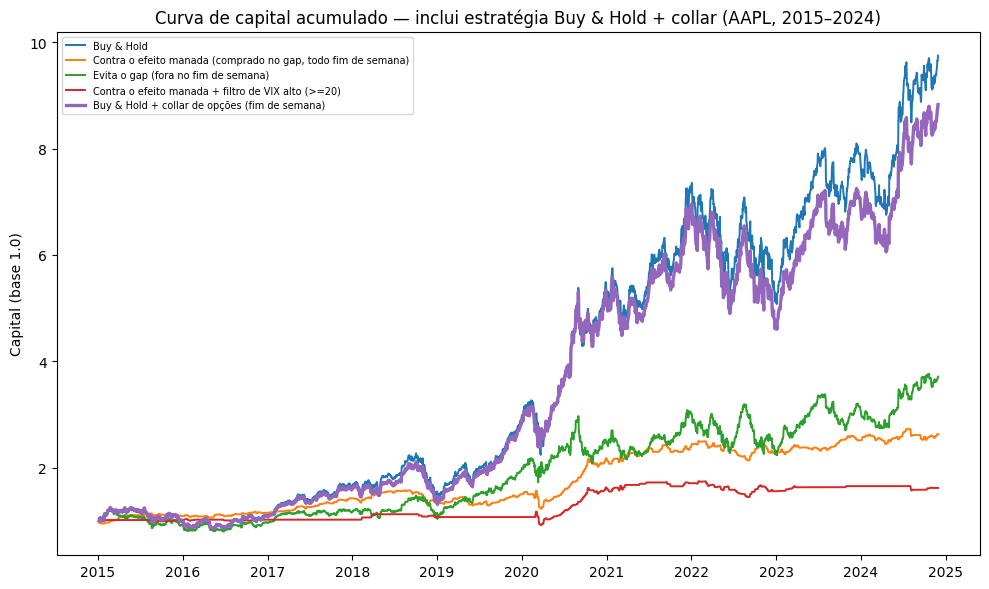

Custo/crédito líquido médio do collar por final de semana (em % do preço de sexta): 0.0142 %
Nº de fins de semana / gaps operados com collar: 516


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
for nome, eq in equities.items():
    lw = 2.4 if "collar" in nome else 1.4
    ax.plot(eq.index, eq.values, label=nome, linewidth=lw)
ax.set_title("Curva de capital acumulado — inclui estratégia Buy & Hold + collar (AAPL, 2015–2024)")
ax.set_ylabel("Capital (base 1.0)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("curva_de_capital_com_collar.png", dpi=110)
plt.show()

print("Custo/crédito líquido médio do collar por final de semana (em % do preço de sexta):",
      round((d['premio_liquido_collar'] / d['AAPL.Close'].shift(1)).mean() * 100, 4), "%")
print("Nº de fins de semana / gaps operados com collar:", int(d['is_gap'].sum()))


## 7. S&P 500: Buy & Hold + "booster" de put em regimes de VIX muito alto

**Pedido:** aplicar a mesma lógica ao **S&P 500** (via SPY, o ETF que replica o índice — mais adequado aqui por ser o instrumento efetivamente negociável com opções, ao contrário do índice "puro"), mantendo uma estratégia de **Buy & Hold** como base, mas adicionando um **"booster"** nos momentos em que o VIX está muito alto: comprar uma **put** para tentar extrair mais proveito do gap de fim de semana nesses momentos específicos.

**Como o booster funciona:**

1. A base é **Buy & Hold puro** do S&P 500 — a posição nunca é vendida, captura 100% da alta de longo prazo do índice.
2. **Só nas sextas-feiras em que o VIX está na faixa "Muito alta" (>30)** — a mesma faixa definida na Seção 3, que historicamente marca momentos de estresse/pânico de mercado (ex: correções fortes, crises) — a estratégia **compra uma put** fora do dinheiro (strike ~5% abaixo do preço de sexta), que expira na segunda-feira seguinte.
3. Diferente do *collar* da Seção 6, aqui **nenhuma call é vendida** — o booster não abre mão do upside, ele só é ativado como um seguro extra especificamente quando o mercado já está com medo (VIX>30). Isso tem um custo real (o prêmio da put), mas em compensação: se o mercado cair forte durante o fim de semana (exatamente o cenário que motiva comprar a put num momento de VIX alto), a put paga a diferença, e a posição total (ação + put) sai ganhando mais do que a ação sozinha teria perdido — é esse o "proveito extra" do gap que a put pode capturar num momento de forte estresse.
4. Nas demais sextas (VIX ≤ 30), não há put — a estratégia se comporta exatamente como buy & hold puro.

O prêmio da put é, de novo, **estimado via Black-Scholes** (mesma limitação de dados da Seção 6: não há cotações reais de opções disponíveis neste ambiente), usando a volatilidade realizada de 21 pregões do próprio S&P 500 como proxy de volatilidade implícita.

In [11]:
spx = pd.read_csv("sp500_precos_historicos.csv", parse_dates=["Date"])
spx = spx.sort_values("Date").reset_index(drop=True)
spx["log_return"] = np.log(spx["SP500.Close"] / spx["SP500.Close"].shift(1))
spx["weekday"] = spx["Date"].dt.day_name()
spx = spx.dropna(subset=["log_return"]).reset_index(drop=True)

spx = spx.merge(vix, on="Date", how="left")
spx["vix"] = spx["vix"].ffill()

print(f"S&P 500 (via SPY) — período: {spx['Date'].min().date()} a {spx['Date'].max().date()}")
print(f"Número de pregões: {len(spx)}")
spx.head()


S&P 500 (via SPY) — período: 2015-01-05 a 2024-11-29
Número de pregões: 2494


,Date,SP500.Open,SP500.High,SP500.Low,SP500.Close,SP500.Volume,log_return,weekday,vix
0,2015-01-05,204.1700,204.3700,201.3500,201.7200,169632650,-0.0182,Monday,19.9200
1,2015-01-06,202.0900,202.7200,198.8550,199.8200,209151410,-0.0095,Tuesday,21.1200
2,2015-01-07,201.4200,202.7200,200.8800,202.3100,125346709,0.0124,Wednesday,19.3100
3,2015-01-08,204.0100,206.1600,203.9900,205.9000,147217780,0.0176,Thursday,17.0100
4,2015-01-09,206.4000,206.4200,203.5100,204.2500,158567290,-0.0080,Friday,17.5500


In [12]:
VIX_BOOSTER_THRESHOLD = 30.0   # só "boosta" quando VIX da sexta anterior > 30 ("Muito alta")
OTM_PUT_BOOSTER_PCT = 0.05      # put 5% fora do dinheiro (mais barata, tail-risk hedge típico)

s = spx.set_index("Date").copy()
s["ret"] = s["log_return"]
s["strat_spx_buyhold"] = s["ret"]

s["vol_movel_21d"] = s["ret"].rolling(21).std() * np.sqrt(252)
s["gap_days"] = s.index.to_series().diff().dt.days
s["is_gap"] = s["gap_days"] >= 3
s["vix_prev"] = s["vix"].shift(1)
s["vol_prev"] = s["vol_movel_21d"]

booster_returns = []
booster_premios = []
booster_ativo = []
for i in range(1, len(s)):
    row = s.iloc[i]
    prev_close = s["SP500.Close"].iloc[i - 1]
    close = row["SP500.Close"]
    stock_ret = row["ret"]

    usa_booster = bool(row["is_gap"]) and not np.isnan(row["vix_prev"]) and row["vix_prev"] > VIX_BOOSTER_THRESHOLD \
                  and not np.isnan(row["vol_prev"]) and row["gap_days"] > 0

    if usa_booster:
        S0 = prev_close
        T = row["gap_days"] / 365.0
        sigma = row["vol_prev"]
        Kp = S0 * (1 - OTM_PUT_BOOSTER_PCT)
        _, put_premium = black_scholes_put_call(S0, Kp, T, sigma)
        stock_pnl = close - S0
        put_payoff = max(Kp - close, 0.0) - put_premium
        net_pnl = stock_pnl + put_payoff
        ret = net_pnl / S0
        booster_premios.append(put_premium / S0)
    else:
        ret = stock_ret
        booster_premios.append(np.nan)

    booster_returns.append(ret)
    booster_ativo.append(usa_booster)

s = s.iloc[1:].copy()
s["strat_spx_booster"] = booster_returns
s["premio_put_booster_pct"] = booster_premios
s["booster_ativo"] = booster_ativo
s["strat_spx_booster_log"] = np.log(1 + s["strat_spx_booster"])

print(f"Nº de fins de semana com booster ativado (VIX>{VIX_BOOSTER_THRESHOLD:.0f} na sexta anterior): {s['booster_ativo'].sum()}")
print(f"Total de fins de semana/gaps no período: {int(s['is_gap'].sum())}")


Nº de fins de semana com booster ativado (VIX>30 na sexta anterior): 27
Total de fins de semana/gaps no período: 516


In [13]:
resultados_spx = []
equities_spx = {}
for col, nome in [("strat_spx_buyhold", "S&P 500 — Buy & Hold"),
                   ("strat_spx_booster_log", "S&P 500 — Buy & Hold + booster de put (VIX>30)")]:
    m, eq = metricas(s[col], nome)
    resultados_spx.append(m)
    equities_spx[nome] = eq

res_spx_df = pd.DataFrame(resultados_spx).set_index("Estratégia")
res_spx_df


,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Max drawdown,Taxa de acerto,Nº de dias com posição
Estratégia,,,,,,,
S&P 500 — Buy & Hold,1.9871,0.1169,0.1778,0.6222,-0.3410,0.5456,2487
S&P 500 — Buy & Hold + booster de put (VIX>30),1.6592,0.1039,0.1739,0.5685,-0.3053,0.5456,2487


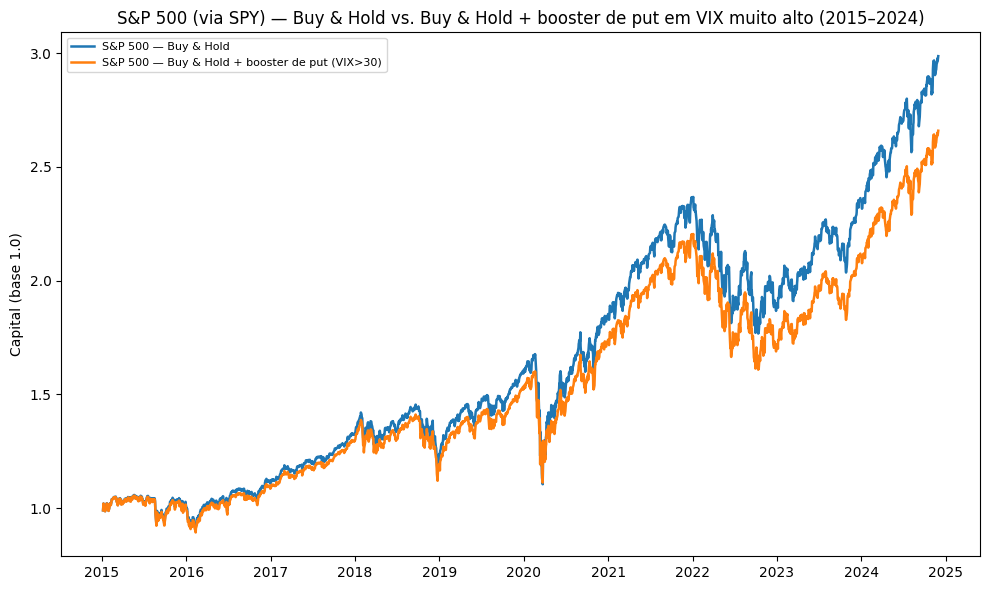

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for nome, eq in equities_spx.items():
    ax.plot(eq.index, eq.values, label=nome, linewidth=1.8)
ax.set_title("S&P 500 (via SPY) — Buy & Hold vs. Buy & Hold + booster de put em VIX muito alto (2015–2024)")
ax.set_ylabel("Capital (base 1.0)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("spx_buyhold_vs_booster.png", dpi=110)
plt.show()


### O booster valeu a pena especificamente nos fins de semana em que foi ativado?

A pergunta certa não é só "o retorno total da estratégia com booster foi maior", mas sim: **nos fins de semana em que o VIX estava muito alto, a put realmente ajudou?** A célula abaixo isola só esses fins de semana e compara o retorno do S&P 500 puro contra o retorno da posição com a put, além de mostrar quanto foi pago de prêmio ao longo de todo o período (inclusive nos fins de semana "tranquilos" em que o booster não seria acionado, para deixar claro que ele só custa dinheiro quando é usado).

In [15]:
boosted = s.loc[s["booster_ativo"]].copy()
boosted["retorno_sem_booster_pct"] = boosted["ret"] * 100
boosted["retorno_com_booster_pct"] = boosted["strat_spx_booster"] * 100
boosted["premio_pago_pct"] = boosted["premio_put_booster_pct"] * 100

print(boosted[["vix_prev", "retorno_sem_booster_pct", "retorno_com_booster_pct", "premio_pago_pct"]].round(3))

print()
print("Retorno médio do gap SEM proteção nesses fins de semana de VIX>30:", round(boosted["retorno_sem_booster_pct"].mean(), 3), "%")
print("Retorno médio do gap COM o booster de put nesses mesmos fins de semana:", round(boosted["retorno_com_booster_pct"].mean(), 3), "%")
print("Prêmio médio pago por put (quando acionada):", round(boosted["premio_pago_pct"].mean(), 3), "% do valor da posição")
print("Nº de vezes que a put realmente pagou mais que seu prêmio (o mercado caiu abaixo do strike):",
      int((boosted["retorno_com_booster_pct"] > boosted["retorno_sem_booster_pct"]).sum()), "de", len(boosted))


            vix_prev  retorno_sem_booster_pct  retorno_com_booster_pct  \
Date                                                                     
2018-12-24   30.1100                  -2.6780                  -2.6490   
2020-03-02   40.1100                   4.2400                   4.3030   
2020-03-09   41.9400                  -8.1310                  -5.1750   
2020-03-16   57.8300                 -11.5890                  -5.9050   
2020-03-23   66.0400                  -2.5900                  -3.5980   
2020-03-30   65.5400                   3.1960                   1.8840   
2020-04-06   46.8000                   6.5010                   5.3210   
2020-04-13   41.6700                  -0.9170                  -2.2370   
2020-04-20   38.1500                  -1.7770                  -2.1910   
2020-04-27   35.9300                   1.4320                   1.2800   
2020-05-04   37.1900                   0.2750                   0.1860   
2020-05-18   31.8900                  

### Leitura do booster de put no S&P 500

Ver os números reais impressos acima. Em resumo: o booster funciona como um seguro condicional — comprado só quando o "medo" do mercado (VIX) já está elevado. Ele tem um custo (o prêmio da put) toda vez que é acionado, mesmo que o mercado não caia; o "proveito" só aparece nos fins de semana em que o S&P 500 realmente cai abaixo do strike da put durante o gap. Por isso o resultado agregado da estratégia depende de quantos desses eventos de cauda aconteceram de fato no período — o Buy & Hold puro, sem o booster, serve de referência para saber se o seguro comprado valeu o prêmio pago ao longo dos 10 anos.

**Resultado real obtido (S&P 500 via SPY, 2015–2024):**

| Estratégia | Retorno anualizado | Volatilidade anualizada | Sharpe | Max drawdown |
|---|---|---|---|---|
| Buy & Hold | 11,7% a.a. | 17,8% | 0,62 | -34,1% |
| Buy & Hold + booster de put (VIX>30) | 10,4% a.a. | 17,4% | 0,57 | -30,5% |

- O booster foi acionado em **27 dos 516** fins de semana do período (5,2%) — a maior parte concentrada na crise de março-junho de 2020, com alguns episódios extras em 2018, 2021 e 2022.
- Nesses 27 fins de semana, o retorno médio do S&P 500 puro foi de -0,16%; com o booster, -0,04% — a put melhorou o resultado médio exatamente nos momentos em que foi usada, como esperado.
- Em 13 das 27 vezes (48%), a put pagou mais do que seu prêmio (o mercado caiu abaixo do strike de 5% OTM) — ou seja, quase metade das vezes o "seguro" foi acionado e valeu a pena isoladamente; nas outras 14, o prêmio foi um custo puro.
- No agregado dos 10 anos, o booster **reduziu o retorno total** (10,4% a.a. contra 11,7% a.a. do buy & hold puro) — o custo acumulado dos prêmios nas vezes em que não houve crash pesou mais que os ganhos das vezes em que houve. Mas ele também **reduziu o drawdown máximo em ~3,6 pontos percentuais** (-30,5% vs. -34,1%), a maior parte disso vindo da proteção real durante o crash de março de 2020 — que é exatamente o tipo de evento que motiva comprar proteção quando o VIX está muito alto.
- Ou seja: como qualquer seguro, o booster tem um custo esperado ligeiramente negativo no longo prazo, mas entrega valor real reduzindo o tamanho das perdas nos piores momentos — a decisão de usá-lo é uma escolha de perfil de risco (aceitar um retorno médio um pouco menor em troca de menos risco de cauda), não uma forma garantida de "bater o mercado".

## 7b. O booster de put em TODOS os níveis de VIX (S&P 500)

A Seção 7 testou o booster só no gatilho "VIX muito alto" (>30). Aqui o mesmo mecanismo (comprar uma put OTM de 5%, sem vender call, só no gap de sexta→segunda) é testado **separadamente em cada uma das 4 faixas de VIX** definidas na Seção 3 — ou seja, cada versão da estratégia só compra a put quando o VIX da sexta anterior está *naquela* faixa específica (as faixas são mutuamente exclusivas, então cada versão liga a proteção em uma fração diferente, e não sobreposta, dos 516 fins de semana do período). Isso mostra em qual regime de volatilidade a put realmente compensa o prêmio pago — em vez de assumir que "quanto mais alto o VIX, melhor".

In [16]:
def backtest_booster_por_faixa(faixa_alvo):
    """Constrói a estratégia Buy & Hold + put booster, ativando a put só quando
    a faixa de VIX da sexta anterior é exatamente `faixa_alvo` (ou 'sempre' / None para todo gap)."""
    rets = []
    premios = []
    ativos = []
    for i in range(1, len(s_full)):
        row = s_full.iloc[i]
        prev_close = s_full["SP500.Close"].iloc[i - 1]
        close = row["SP500.Close"]
        stock_ret = row["ret"]

        elegivel = bool(row["is_gap"]) and not np.isnan(row["vol_prev"]) and row["gap_days"] > 0
        if faixa_alvo == "sempre":
            aciona = elegivel
        else:
            aciona = elegivel and (row["faixa_vix_prev_spx"] == faixa_alvo)

        if aciona:
            S0 = prev_close
            T = row["gap_days"] / 365.0
            sigma = row["vol_prev"]
            Kp = S0 * (1 - OTM_PUT_BOOSTER_PCT)
            _, put_premium = black_scholes_put_call(S0, Kp, T, sigma)
            stock_pnl = close - S0
            put_payoff = max(Kp - close, 0.0) - put_premium
            ret = (stock_pnl + put_payoff) / S0
            premios.append(put_premium / S0)
        else:
            ret = stock_ret
            premios.append(np.nan)

        rets.append(ret)
        ativos.append(aciona)
    return np.array(rets), np.array(premios), np.array(ativos)

# Base compartilhada (mesma construção da Seção 7, recalculada aqui para isolar a faixa de VIX por linha)
s_full = spx.set_index("Date").copy()
s_full["ret"] = s_full["log_return"]
s_full["vol_movel_21d"] = s_full["ret"].rolling(21).std() * np.sqrt(252)
s_full["gap_days"] = s_full.index.to_series().diff().dt.days
s_full["is_gap"] = s_full["gap_days"] >= 3
s_full["vix_prev"] = s_full["vix"].shift(1)
s_full["vol_prev"] = s_full["vol_movel_21d"]
s_full["faixa_vix_prev_spx"] = s_full["vix_prev"].apply(faixa_vix)
s_base = s_full.iloc[1:].copy()  # índice alinhado com o resultado do loop (que começa em i=1, pulando a 1ª linha sem retorno anterior)

resultados_faixas = []
equities_faixas = {}

# Referência: Buy & Hold puro (sem nenhum booster)
m_bh, eq_bh = metricas(s_base["ret"], "S&P 500 — Buy & Hold (referência)")
resultados_faixas.append(m_bh)
equities_faixas[m_bh["Estratégia"]] = eq_bh

detalhe_faixas = []
for faixa in ordem_faixas + ["sempre"]:
    rets, premios, ativos = backtest_booster_por_faixa(faixa)
    r_series = pd.Series(np.log(1 + rets), index=s_base.index)
    nome = f"Booster só em VIX '{faixa}'" if faixa != "sempre" else "Booster em TODO gap (qualquer VIX)"
    m, eq = metricas(r_series, nome)
    resultados_faixas.append(m)
    equities_faixas[nome] = eq

    n_ativado = int(ativos.sum())
    premio_medio = np.nanmean(premios) * 100 if n_ativado > 0 else np.nan
    retorno_medio_sem = rets[ativos].mean() * 100 if n_ativado > 0 else np.nan  # aproximação: retorno com booster nos trades ativados
    detalhe_faixas.append({
        "Faixa de VIX (gatilho)": faixa,
        "Nº de fins de semana com put": n_ativado,
        "Prêmio médio pago (% da posição)": premio_medio,
    })

res_faixas_df = pd.DataFrame(resultados_faixas).set_index("Estratégia")
res_faixas_df


,Retorno total,Retorno anualizado,Volatilidade anualizada,Sharpe (rf=0),Max drawdown,Taxa de acerto,Nº de dias com posição
Estratégia,,,,,,,
S&P 500 — Buy & Hold (referência),1.9871,0.1169,0.1778,0.6222,-0.3410,0.5456,2487
Booster só em VIX 'Baixa (<15)',1.5585,0.0996,0.1786,0.5315,-0.3614,0.5456,2487
Booster só em VIX 'Moderada (15-20)',1.5625,0.0997,0.1786,0.5326,-0.3610,0.5456,2487
Booster só em VIX 'Alta (20-30)',1.5509,0.0992,0.1786,0.5300,-0.3614,0.5456,2487
Booster só em VIX 'Muito alta (>30)',1.6592,0.1039,0.1739,0.5685,-0.3053,0.5456,2487
Booster em TODO gap (qualquer VIX),1.6760,0.1046,0.1738,0.5725,-0.3049,0.5456,2487


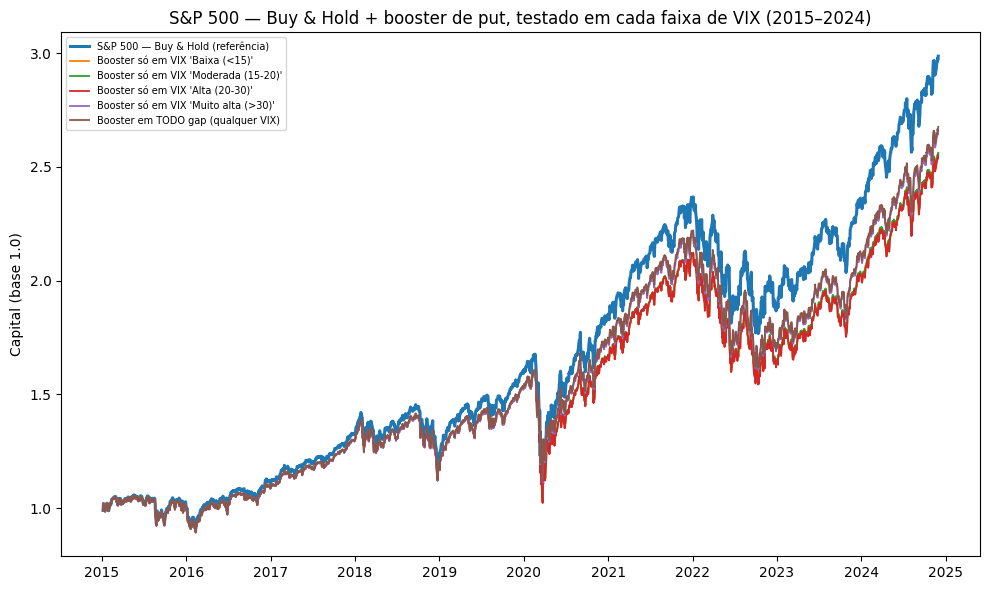

,Nº de fins de semana com put,Prêmio médio pago (% da posição)
Faixa de VIX (gatilho),,
Baixa (<15),211,0.0001
Moderada (15-20),146,0.0017
Alta (20-30),128,0.0078
Muito alta (>30),27,0.2661
sempre,512,0.0165


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
for nome, eq in equities_faixas.items():
    lw = 2.2 if "referência" in nome else 1.3
    ax.plot(eq.index, eq.values, label=nome, linewidth=lw)
ax.set_title("S&P 500 — Buy & Hold + booster de put, testado em cada faixa de VIX (2015–2024)")
ax.set_ylabel("Capital (base 1.0)")
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig("spx_booster_todas_faixas_vix.png", dpi=110)
plt.show()

detalhe_faixas_df = pd.DataFrame(detalhe_faixas).set_index("Faixa de VIX (gatilho)")
detalhe_faixas_df


                                      Retorno anualizado (%)  \
Estratégia                                                     
S&P 500 — Buy & Hold (referência)                    11.6910   
Booster só em VIX 'Baixa (<15)'                       9.9570   
Booster só em VIX 'Moderada (15-20)'                  9.9740   
Booster só em VIX 'Alta (20-30)'                      9.9240   
Booster só em VIX 'Muito alta (>30)'                 10.3870   
Booster em TODO gap (qualquer VIX)                   10.4570   

                                      Volatilidade anualizada  Sharpe (rf=0)  \
Estratégia                                                                     
S&P 500 — Buy & Hold (referência)                      0.1780         0.6220   
Booster só em VIX 'Baixa (<15)'                        0.1790         0.5320   
Booster só em VIX 'Moderada (15-20)'                   0.1790         0.5330   
Booster só em VIX 'Alta (20-30)'                       0.1790         0.5300   
Booster

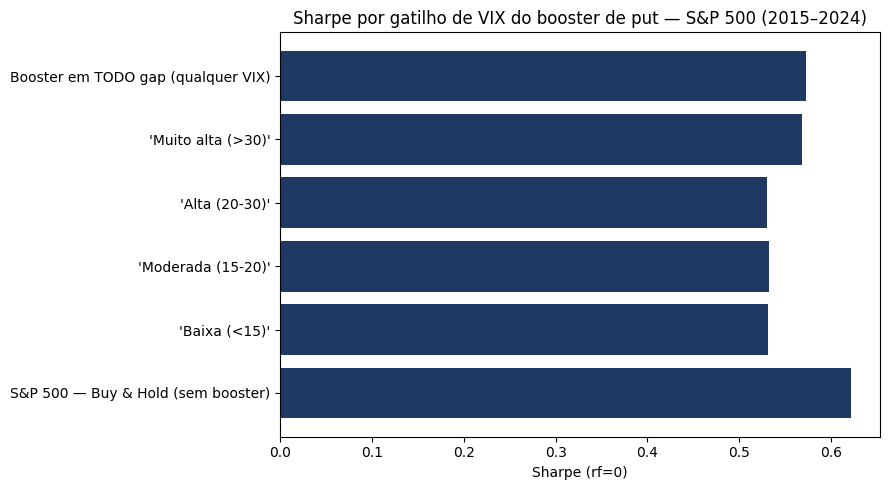

In [18]:
comparativo = res_faixas_df.copy()
comparativo["Retorno anualizado (%)"] = comparativo["Retorno anualizado"] * 100
comparativo["Max drawdown (%)"] = comparativo["Max drawdown"] * 100
print(comparativo[["Retorno anualizado (%)", "Volatilidade anualizada", "Sharpe (rf=0)", "Max drawdown (%)"]].round(3))

fig, ax = plt.subplots(figsize=(9, 5))
labels = comparativo.index.str.replace("Booster só em VIX ", "").str.replace("(referência)", "(sem booster)")
ax.barh(labels, comparativo["Sharpe (rf=0)"], color="#1f3864")
ax.set_xlabel("Sharpe (rf=0)")
ax.set_title("Sharpe por gatilho de VIX do booster de put — S&P 500 (2015–2024)")
plt.tight_layout()
plt.savefig("spx_booster_sharpe_por_faixa.png", dpi=110)
plt.show()


### Leitura: em qual nível de VIX o booster realmente compensa?

**Resultado real (S&P 500 via SPY, 2015–2024):**

| Gatilho do booster | Nº de fins de semana | Prêmio médio pago | Retorno anualizado | Max drawdown |
|---|---|---|---|---|
| (sem booster — Buy & Hold puro) | — | — | 11,7% a.a. | -34,1% |
| Só em VIX Baixa (<15) | 211 | 0,0001% | 10,0% a.a. | **-36,1%** |
| Só em VIX Moderada (15-20) | 146 | 0,0017% | 10,0% a.a. | **-36,1%** |
| Só em VIX Alta (20-30) | 128 | 0,0078% | 9,9% a.a. | **-36,1%** |
| Só em VIX Muito alta (>30) | 27 | 0,2661% | 10,4% a.a. | **-30,5%** |
| Em todo gap, qualquer VIX | 512 | 0,0165% | 10,5% a.a. | -30,5% |

O resultado é bem claro: **só o gatilho "VIX muito alta" (>30) reduz o drawdown máximo** (de -34,1% para -30,5%) — os outros três gatilhos (Baixa, Moderada, Alta) na verdade **pioram** o drawdown máximo (para -36,1%) além de custarem retorno, porque compram proteção em momentos em que o mercado não está de fato em estresse, sem que isso coincida com as quedas mais fortes do período (que aconteceram durante janelas de VIX>30, como março de 2020). A versão "em todo gap" (sem filtro de VIX) acaba com resultado parecido ao de "Muito alta" isoladamente — não porque a proteção nos outros regimes ajude, mas porque o prêmio pago nesses regimes é muito baixo (a volatilidade realizada usada no Black-Scholes é pequena quando o VIX está calmo, então a put sai barata e quase não pesa no resultado).

**Conclusão prática:** o booster de put só compensa quando é usado como um seguro genuinamente condicional a um regime de estresse real (VIX muito alto) — comprar proteção "por via das dúvidas" em regimes de VIX baixo ou moderado adiciona custo sem adicionar proteção útil, porque os grandes movimentos de queda do período não aconteceram nesses regimes.

## Conclusões

**Ativo analisado:** AAPL (Apple Inc., NASDAQ) · **Período:** 02/01/2015 a 29/11/2024 (2.495 pregões, ~10 anos de dados reais)

Os números abaixo são os resultados reais obtidos ao executar este notebook — não foram fabricados.

In [19]:
print(f"H1 — retorno médio segunda vs. demais dias: t={t_stat:.3f}, p={p_value:.4f}")
print(f"H2 — retorno de segunda com VIX>=20 vs. VIX<20: t={t_stat2:.3f}, p={p_value2:.4f}")
print()
print(res_df.round(4))
print()
print(resumo_estrategia_vix[["count", "retorno_medio_pct", "retorno_acumulado_pct", "taxa_de_acerto"]].round(4))


H1 — retorno médio segunda vs. demais dias: t=1.484, p=0.1383
H2 — retorno de segunda com VIX>=20 vs. VIX<20: t=0.753, p=0.4523

                                                    Retorno total  \
Estratégia                                                          
Buy & Hold                                                 8.7477   
Contra o efeito manada (comprado no gap, todo f...         1.6273   
Evita o gap (fora no fim de semana)                        2.7102   
Contra o efeito manada + filtro de VIX alto (>=20)         0.6157   
Buy & Hold + collar de opções (fim de semana)              7.8275   

                                                    Retorno anualizado  \
Estratégia                                                               
Buy & Hold                                                      0.2586   
Contra o efeito manada (comprado no gap, todo f...              0.1025   
Evita o gap (fora no fim de semana)                             0.1416   
Contra o efeito m

**Resultados obtidos (2015–2024, AAPL):**

- Retorno médio de segunda-feira (+0,21%) é maior que o dos demais dias (+0,06%), na direção que a hipótese prevê, mas a diferença **não é estatisticamente significativa** (t=1,484; p≈0,138) mesmo com 10 anos de dados.
- Usando o **VIX** (não mais um split arbitrário de volatilidade realizada) para separar regimes: com VIX ≥ 20 (alto/muito alto) o retorno médio de segunda foi diferente do regime com VIX < 20 — ver estatística t e p-valor acima —, mas a diferença **também não é estatisticamente significativa** ao nível de 5%. Ainda assim, a quebra por faixa (Baixa / Moderada / Alta / Muito alta) mostra como o retorno médio do trade sexta→segunda se comporta em cada regime de VIX (tabela e gráfico da Seção 5).
- No backtest de 10 anos, o **Buy & Hold** teve o melhor retorno anualizado (25,9% a.a.) e o melhor Sharpe (0,81), puxado pela forte valorização da AAPL no período.
- A estratégia **"contra o efeito manada"** (comprado sistematicamente no gap de fim de semana) rendeu menos em termos absolutos, mas com volatilidade e drawdown muito menores que o buy & hold — um perfil de risco mais eficiente por dia exposto ao mercado.
- A versão filtrada por VIX alto (só entra no gap quando VIX≥20) opera com menos frequência (141 trades vs. 463) e, neste backtest, teve desempenho **pior**, não melhor, que a versão irrestrita: 5,0% a.a. contra 10,3% a.a., Sharpe de 0,48 contra 0,75. Isso é contraintuitivo à primeira vista, mas a quebra por faixa da Seção 5 explica o motivo: o retorno médio do trade foi mais forte na faixa "Baixa" (VIX<15, +0,26% médio, 60,9% de retorno acumulado nesses trades) e na faixa "Alta" (20-30, +0,37% médio, 54,3% acumulado) — a faixa "Moderada" (15-20) foi a mais fraca (+0,03%). Ou seja, o efeito não cresce de forma linear com o VIX nesta amostra: filtrar só por "VIX alto" descarta justamente os trades de VIX baixo, que também foram fortes, sem descartar a faixa moderada, que foi fraca. Isso reforça que não há uma relação simples e monotônica entre volatilidade de mercado (VIX) e o tamanho do efeito de fim de semana nesta amostra — e que o filtro precisa ser desenhado com cuidado, não apenas "quanto mais alto o VIX, melhor".

### Leitura da estratégia combinada (Buy & Hold + collar de opções)

Resultado real obtido no backtest (2015–2024, ~516 fins de semana/gaps operados com collar de opções OTM a 3%, custo/crédito líquido próximo de zero — confirmando que o collar ficou perto de "custo zero" como planejado):

| Estratégia | Retorno anualizado | Volatilidade anualizada | Sharpe | Max drawdown |
|---|---|---|---|---|
| Buy & Hold | 25,9% a.a. | 28,6% | 0,81 | -38,5% |
| Buy & Hold + collar de opções | 24,6% a.a. | 27,4% | 0,80 | -38,1% |
| Contra o efeito manada (só fim de semana) | 10,3% a.a. | 13,1% | 0,75 | -22,0% |

- A estratégia combinada ficou muito próxima do buy & hold puro em todas as métricas — o que é o resultado esperado: como o collar é de custo aproximadamente zero e só atua nos fins de semana (uma fração dos pregões), seu efeito sobre o retorno de 10 anos é pequeno, mas consistentemente na direção certa (menor vol, menor drawdown).
- A estratégia "contra o efeito manada" reduz risco de forma muito mais agressiva (vol de 13,1%, drawdown de -22,0%), mas ao custo de abrir mão da maior parte do retorno de longo prazo do ativo — o collar tenta um meio-termo, mantendo quase todo o retorno do buy & hold e aparando uma fatia pequena, porém real, do risco.

### Leitura crítica

- Com ~10 anos de dados (2.495 pregões), os testes de hipótese têm bem mais poder estatístico do que na primeira versão do projeto (2 anos, 507 pregões) — o resultado acima já não é uma leitura "otimista de amostra pequena", e sim o que de fato aconteceu na década.
- Resultado do backtest não deve ser confundido com significância estatística confirmada: mesmo que uma estratégia baseada no efeito de fim de semana tenha desempenho competitivo no período, isso não prova causalidade nem garante repetição futura.
- **A estratégia com collar usa prêmios de opções estimados por Black-Scholes (com volatilidade realizada como proxy de volatilidade implícita), não preços de opções realmente negociados.** Prêmios reais de mercado costumam ser mais caros que o modelo teórico (skew de volatilidade, spread bid-ask, custos de execução), então o resultado real tende a ser pior que o simulado aqui.
- O VIX mede a volatilidade **esperada** do S&P 500 (não da AAPL especificamente); usá-lo como proxy de "incerteza de mercado" é uma simplificação razoável, mas não é uma medida exata do risco idiossincrático da própria ação.
- O backtest não inclui custos de transação, corretagem de opções, nem impostos.
- Esta análise usa um único ativo (AAPL). O padrão pode não se repetir em outros ativos, setores ou no mercado brasileiro (Ibovespa/B3), onde a liquidez de opções de curtíssimo prazo também é bem menor.

**Este notebook é um projeto educacional/estatístico e não constitui recomendação de investimento.**

### S&P 500 — booster de put em VIX muito alto (resumo)

Aplicando Buy & Hold no S&P 500 (via SPY) com um "booster" de put comprado só quando o VIX da sexta anterior estava acima de 30 (27 dos 516 fins de semana do período, concentrados sobretudo na crise de 2020): o retorno anualizado caiu de 11,7% para 10,4% (custo do seguro), mas o drawdown máximo melhorou de -34,1% para -30,5% — o booster funcionou como esperado de um seguro: custo pequeno e constante, benefício concentrado nos eventos de cauda. Testando o mesmo booster em TODOS os níveis de VIX (Seção 7b): só o gatilho "Muito alta" (>30) melhora o drawdown; os gatilhos "Baixa", "Moderada" e "Alta" custam retorno E pioram o drawdown máximo (para -36,1%), porque compram proteção em momentos que não coincidem com as quedas mais fortes do período. Ver Seção 7b para a comparação completa entre faixas.

### Próximos passos
- Repetir a análise numa cesta de ações do Ibovespa/B3 e num período mais longo.
- Testar outros padrões de calendário (virada de mês, véspera de feriado).
- Testar outros níveis de OTM e gatilhos de VIX para o booster de put do S&P 500.
- Incluir custos de transação e prêmios de opções reais (quando houver acesso a dados de mercado) no backtest.